<a href="https://colab.research.google.com/github/Arieltian06/TugasAI_Kelompok/blob/main/Matkul_AI_TugasKelompok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modul 1

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('insurance.csv')

In [39]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [40]:
X = df[['bmi']].values
y = df['charges'].values

In [41]:
# Inisialisasi parameter
w = 0
b = 0
lr = 0.0001
epochs = 1000

n = len(X)

for i in range(epochs):
    for j in range(n):
        x_i = X[j][0]
        y_i = y[j]

        y_pred = w * x_i + b

        # hitung gradien
        dw = -2 * x_i * (y_i - y_pred)
        db = -2 * (y_i - y_pred)

        # update
        w = w - lr * dw
        b = b - lr * db

print("w:", w)
print("b:", b)

w: 327.9645655705848
b: 328.97502514626234


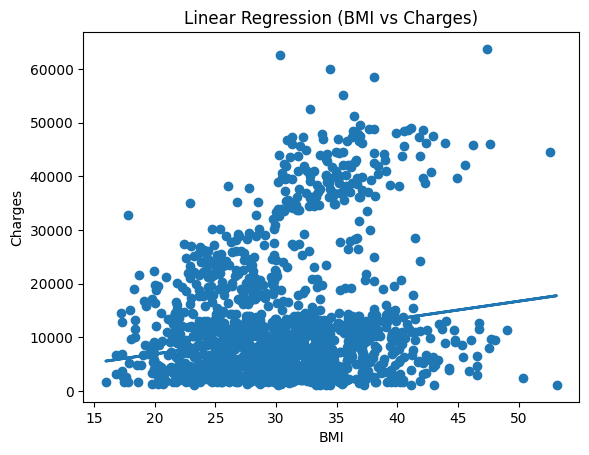

In [42]:
# Prediksi garis regresi
y_pred_line = w * X + b

plt.scatter(X, y)
plt.plot(X, y_pred_line, linewidth=2)

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Linear Regression (BMI vs Charges)")

plt.show()

#Modul 2

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv('train.csv')

In [45]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [46]:
X = df[['ram', 'battery_power']].values
y = df['price_range'].values

In [47]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [48]:
num_classes = 4
y_onehot = np.eye(num_classes)[y]

In [49]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [50]:
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

In [51]:
np.random.seed(0)

n_features = X.shape[1]
n_classes = 4

W = np.random.randn(n_features, n_classes)
b = np.zeros((1, n_classes))

In [52]:
lr = 0.01
epochs = 1000

for epoch in range(epochs):

    # Forward
    logits = np.dot(X, W) + b
    y_pred = softmax(logits)

    # Loss
    loss = cross_entropy(y_onehot, y_pred)

    # Gradien
    dW = np.dot(X.T, (y_pred - y_onehot)) / len(X)
    db = np.sum(y_pred - y_onehot, axis=0, keepdims=True) / len(X)

    # Update
    W -= lr * dW
    b -= lr * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 2.0046
Epoch 100, Loss: 1.6570
Epoch 200, Loss: 1.4078
Epoch 300, Loss: 1.2297
Epoch 400, Loss: 1.1026
Epoch 500, Loss: 1.0127
Epoch 600, Loss: 0.9491
Epoch 700, Loss: 0.9030
Epoch 800, Loss: 0.8684
Epoch 900, Loss: 0.8415


In [53]:
y_pred_class = np.argmax(y_pred, axis=1)
accuracy = np.mean(y_pred_class == y)

print("Accuracy:", accuracy)

Accuracy: 0.6755


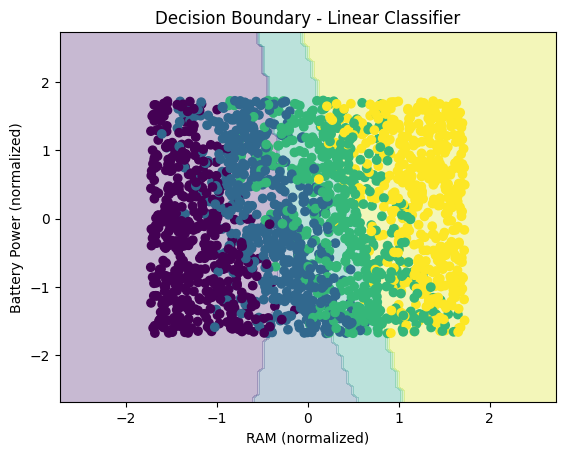

In [54]:
# grid
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# prediksi grid
Z = np.dot(grid, W) + b
Z = softmax(Z)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

# plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)

plt.xlabel("RAM (normalized)")
plt.ylabel("Battery Power (normalized)")
plt.title("Decision Boundary - Linear Classifier")

plt.show()